In [18]:
%pip uninstall sagemaker -y
%pip install "sagemaker>=2.0,<3.0" -q
!pip install tensorflow-io -q

Found existing installation: sagemaker 2.257.3


Uninstalling sagemaker-2.257.3:
  Successfully uninstalled sagemaker-2.257.3


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [19]:
!pip install pydicom opencv-python-headless --quiet

#### imports

In [20]:
import sagemaker
from sagemaker.feature_store.feature_group import FeatureGroup
import boto3
import pydicom
import tensorflow_io as tfio

In [21]:
import sys
sys.path.insert(0, 'FinalProject/')
from config import BUCKET_NAME, IMG_SIZE, BATCH_SIZE
from img_preprocessing import load_image_from_s3

In [22]:
import awswrangler as wr

df_meta = wr.athena.read_sql_query(
    "SELECT * FROM pneumonia_db.image_metadata",
    database="pneumonia_db"
)


print(f"Total images to process: {len(df_meta)}")

Total images to process: 32540


In [23]:
# This will show you the S3 LOCATION the table is registered with
table_info = wr.catalog.get_table_types(
    database="pneumonia_db",
    table="image_metadata"
)
print(table_info)

{'image_id': 'string', 'raw_s3_key': 'string', 'preprocessed_s3_key': 'string', 'label': 'string', 'label_int': 'tinyint', 'source': 'string', 'file_type': 'string', 'pixel_mean': 'double', 'pixel_std': 'double', 'img_height': 'int', 'img_width': 'int', 'event_time': 'string'}


### Grab Small Subset of data for initial dev

In [24]:
subset_df = df_meta.sample(1000)

In [25]:
subset_df['full_prepro_s3_path'] = "s3://" + BUCKET_NAME + "/" + subset_df['preprocessed_s3_key']

In [26]:
subset_df.label_int.value_counts()

label_int
0    682
1    318
Name: count, dtype: Int64

#### split into train, test, val, and production

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
split_1, split_2 = train_test_split(subset_df, test_size=.5)

In [29]:
split_1 = split_1.reset_index(drop=True)
split_2 = split_2.reset_index(drop=True)

In [30]:
train_df, test_df = train_test_split(split_1, train_size=.8)
prod_df, val_df = train_test_split(split_2, train_size=.8)

In [31]:
len(test_df)

100

In [32]:
# benchmark_dir = "mini-model-data"
# os.makedirs(benchmark_dir, exist_ok=True)


# train_path = f"{benchmark_dir}/train.csv"
# val_path = f"{benchmark_dir}/validation.csv"
# test_path = f"{benchmark_dir}/test.csv"

# train_df.to_csv(train_path, index=False)
# val_df.to_csv(val_path, index=False)
# test_df.to_csv(test_path, index=False)

# print(f"Train shape: {train_df.shape}")
# print(f"Validation shape: {val_df.shape}")
# print(f"Test shape: {test_df.shape}")

#### build tensorflow datasets

In [33]:
import tensorflow as tf

In [34]:
train_df.head(2)

,image_id,raw_s3_key,preprocessed_s3_key,label,label_int,source,file_type,pixel_mean,pixel_std,img_height,img_width,event_time,full_prepro_s3_path
97,9ebb6f78-9a39-466f-b5cd-bc0eefb7179f,raw-images/rsna-pneumonia/stage_2_train_images...,preprocessed-images/PNEUMONIA/9ebb6f78-9a39-46...,PNEUMONIA,1,rsna,dcm,113.1535,54.2582,512,512,2026-06-07T22:24:54Z,s3://pneumonia-data-set-group-4/preprocessed-i...
456,d5cbd64c-322b-4460-ad0e-c9a23e781f3e,raw-images/rsna-pneumonia/stage_2_train_images...,preprocessed-images/PNEUMONIA/d5cbd64c-322b-44...,PNEUMONIA,1,rsna,dcm,165.0558,55.6513,512,512,2026-06-07T22:28:34Z,s3://pneumonia-data-set-group-4/preprocessed-i...


In [35]:
train_df.file_type.unique()

<StringArray>
['dcm', 'jpeg']
Length: 2, dtype: string

In [36]:
label_map = {}
for dic in subset_df.to_dict(orient='records'):
    label_map[dic['preprocessed_s3_key']] = dic['label_int']

In [37]:
import boto3

s3 = boto3.client("s3")

In [38]:
import matplotlib.pyplot as plt
import numpy as np
AUTOTUNE = tf.data.AUTOTUNE

In [63]:
def load_sample(s3_path, label):
    def _read_and_decode(path_bytes):
        path = path_bytes.decode("utf-8")
        bucket, key = path.replace("s3://", "").split("/", 1)
        obj = s3.get_object(Bucket=bucket, Key=key)
        img = Image.open(BytesIO(obj["Body"].read())).convert("L")  # L = grayscale
        arr = np.array(img, dtype=np.float32)  # (512, 512)
        arr = arr[:, :, np.newaxis]             # (512, 512, 1)
        return arr

    image = tf.numpy_function(_read_and_decode, [s3_path], tf.float32)
    image.set_shape([*IMG_SIZE, 1]) 
    return image, label

In [64]:
def make_ts_dataset(df, shuffle=False):
    paths = df.full_prepro_s3_path.values
    labels = df.label_int.values.astype(int)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df),
                        reshuffle_each_iteration=True
                        )
        
    ds = ds.map(load_sample)
    
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds

In [ ]:
# paths = train_df.full_prepro_s3_path.values
# labels = train_df.label_int.values.astype(int)
# train_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
# train_ds = train_ds.map(load_sample)

In [66]:
train_ds = make_ts_dataset(train_df, True)
test_ds = make_ts_dataset(test_df, False)
val_ds = make_ts_dataset(val_df, False)


In [67]:
import boto3
import pydicom
import matplotlib.pyplot as plt
from io import BytesIO

s3 = boto3.client("s3")
bucket = BUCKET_NAME
key = train_df["full_prepro_s3_path"].iloc[0].replace(f"s3://{bucket}/", "")

obj = s3.get_object(Bucket=bucket, Key=key)
img_bytes = obj["Body"].read()

# Check what PIL sees
from PIL import Image
img = Image.open(BytesIO(img_bytes))
print(img.size)   # (W, H)
print(img.mode)   # L = grayscale, RGB, etc.

(512, 512)
L


(512, 512, 1)


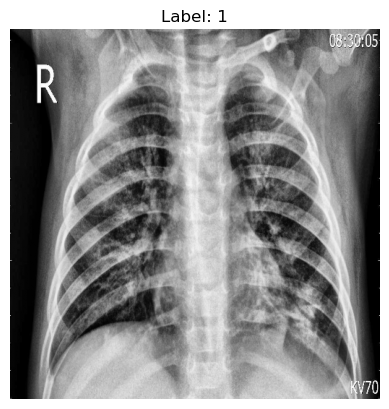

2026-06-11 14:47:03.330963: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [68]:
for image, label in train_ds.take(1):
    #print(images.shape)
    image = image[0]
    label = label[0]
    print(image.shape)
   # label = labels.numpy()[0]  # index into numpy array instead
    
    plt.imshow(image.numpy(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

### Building the Model

In [69]:
import keras
from keras import layers

In [70]:
model_layers = [
    layers.Input(shape=(*IMG_SIZE, 1)), 
    layers.Conv2D(32, kernel_size=3, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, kernel_size=3, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, kernel_size=3, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    
    layers.Conv2D(128, kernel_size=3, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, kernel_size=3, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.GlobalAveragePooling2D(), # this takes the place of flattening, be wary its more location invariant which can be good or bad
    layers.Dense(128, activation='relu'),
    layers.Dropout(.8),
    layers.Dense(16, activation='relu'),
    layers.Dropout(.8),
    layers.Dense(1, activation='sigmoid')
]
model = keras.Sequential(model_layers)

In [71]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam',
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC()  
    ]
)

In [72]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 512, 512, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512, 512, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 512, 512, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         2,06

 Total params: 297,441 (1.13 MB)

 Trainable params: 296,609 (1.13 MB)

 Non-trainable params: 832 (3.25 KB)

### training the model

In [73]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds
)

Epoch 1/20


2026-06-11 14:47:39.890892: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1073741824 exceeds 10% of free system memory.


2026-06-11 14:47:40.870810: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1073741824 exceeds 10% of free system memory.


2026-06-11 14:47:41.668455: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1073741824 exceeds 10% of free system memory.


2026-06-11 14:47:42.227569: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 268435456 exceeds 10% of free system memory.
2026-06-11 14:47:42.399734: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 536870912 exceeds 10% of free system memory.


...

 6/13 ━━━━━━━━━━━━━━━━━━━━ 2:46 24s/step - accuracy: 0.6060 - loss: 0.6484

 7/13 ━━━━━━━━━━━━━━━━━━━━ 2:22 24s/step - accuracy: 0.6055 - loss: 0.6498

 8/13 ━━━━━━━━━━━━━━━━━━━━ 1:59 24s/step - accuracy: 0.6070 - loss: 0.6496

 9/13 ━━━━━━━━━━━━━━━━━━━━ 1:35 24s/step - accuracy: 0.6078 - loss: 0.6501

10/13 ━━━━━━━━━━━━━━━━━━━━ 1:11 24s/step - accuracy: 0.6077 - loss: 0.6508

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss
axes[0].plot(history.history["loss"],     label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# accuracy
axes[1].plot(history.history["accuracy"],     label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test loss:     {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")